# Task 2: Hands-On Data Lab — Module 02: Advanced Data Visualization

## 1. Overview & Objectives
Effective visualization translates raw figures into intuitive, statistically grounded narratives. In this lab, we build univariate, bivariate, and multivariate visualizations using `matplotlib` and `seaborn`.

**Core Learning Objectives:**
- **Univariate Analysis:** Understand feature distributions, skewness, and central tendencies using Histograms and Kernel Density Estimation (KDE).
- **Bivariate Analysis:** Evaluate pairwise demographic relationships and category proportions using count plots, bar plots, and box plots.
- **Multivariate Analysis:** Analyze multi-feature interactions using correlation heatmaps, violin plots, and facet grids.
- **Export Quality:** Programmatically export publication-ready high-resolution (`300 DPI`) figures into the `images/` directory for inclusion in the final Word assessment report.

---

## 2. Setup & Library Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


# Visual styling configuration
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load cleaned dataset from Module 01
csv_path = 'E:/programming/Machine-Learning-Engineer-Internship/Task-2-Hand-on Data implementation/data/titanic_manipulated.csv' 

df = pd.read_csv(csv_path)

print(f"Loaded dataset successfully with shape: {df.shape}")

Loaded dataset successfully with shape: (891, 16)


---

## 3. Univariate Visualizations: Distributions & Skewness
Analyzing continuous variables (`Age`, `Fare`) and categorical frequencies.

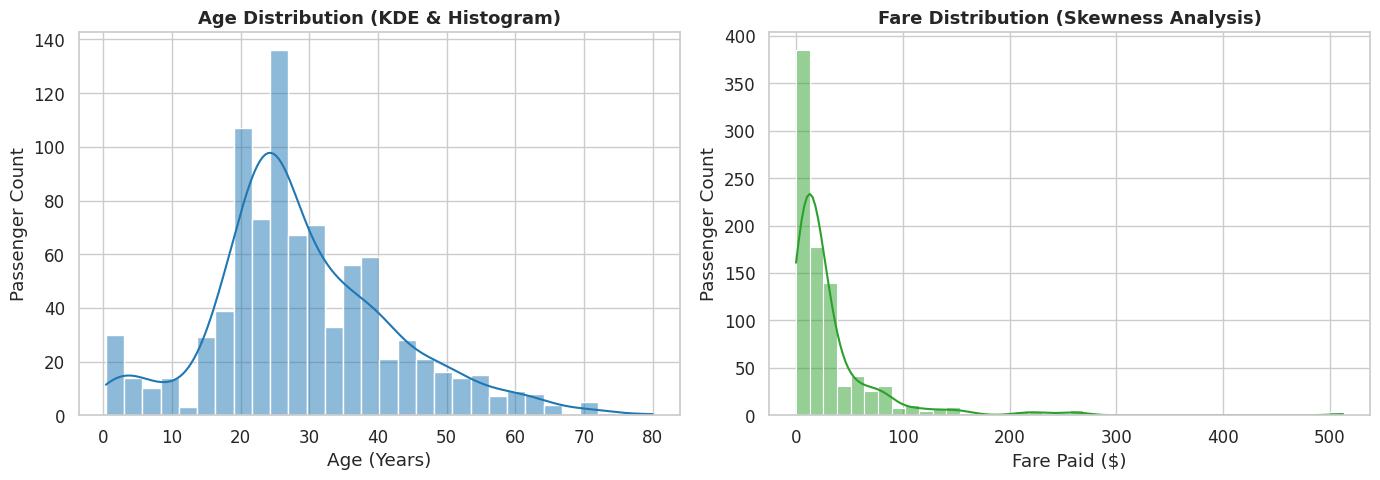

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Age Distribution with KDE
sns.histplot(df['age'], kde=True, bins=30, color='#1f77b4', ax=axes[0])
axes[0].set_title('Age Distribution (KDE & Histogram)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Passenger Count')

# 2. Fare Distribution (Right-skewed)
sns.histplot(df['fare'], kde=True, bins=40, color='#2ca02c', ax=axes[1])
axes[1].set_title('Fare Distribution (Skewness Analysis)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fare Paid ($)')
axes[1].set_ylabel('Passenger Count')

plt.tight_layout()
plt.savefig('../images/01_univariate_distributions.png', dpi=300)
plt.show()

**Analytical Insights:**
- **Age:** Displays a moderately normal distribution centered around the 25–35 age bracket, with a notable minor peak for infants and young children.
- **Fare:** Displays extreme positive (right) skewness, where the vast majority paid under $50, while a small elite cluster paid upwards of $200–$500.

---

## 4. Bivariate Visualizations: Categorical & Survival Interactions
Evaluating survival proportions across gender, socio-economic class, and family size.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18332\4059509909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='survived', data=df, palette='Blues_d', ax=axes[0], errorbar=None)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18332\4059509909.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='pclass', y='survived', data=df, palette='Greens_d', ax=axes[1], errorbar=None)
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_18332\4059509909.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='family_size', y='survived', data=df, pal

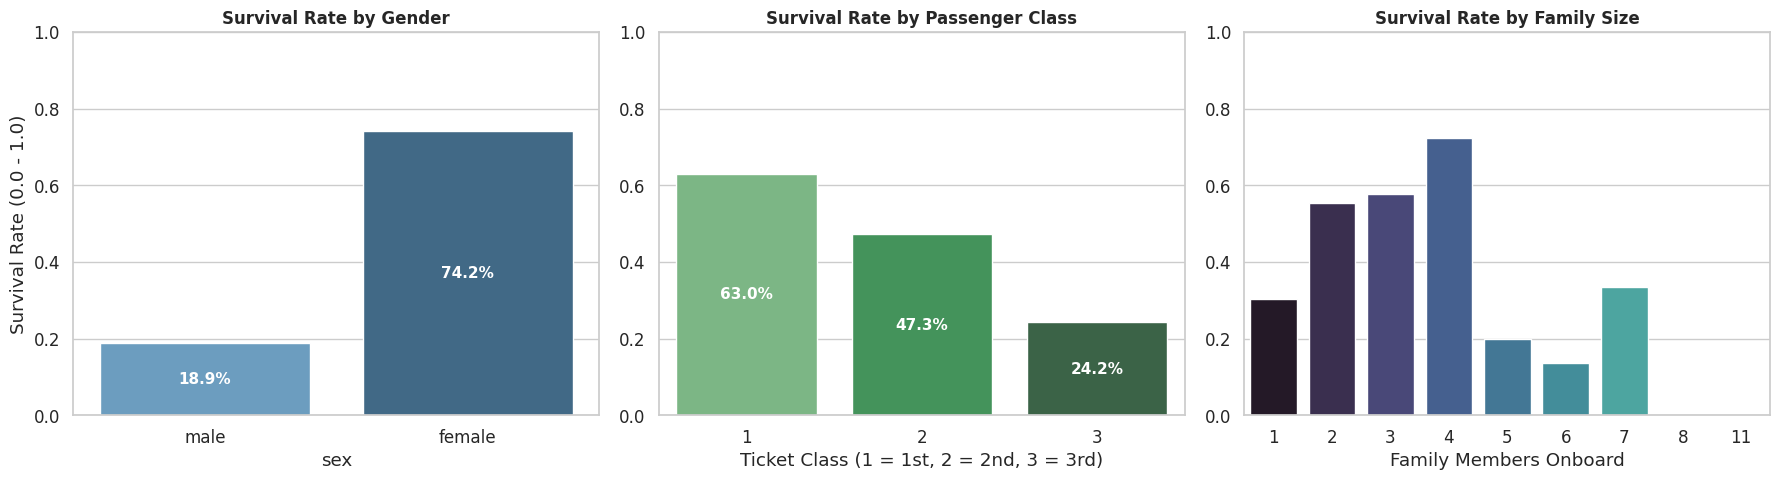

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Survival Rate by Gender
sns.barplot(x='sex', y='survived', data=df, palette='Blues_d', ax=axes[0], errorbar=None)
axes[0].set_title('Survival Rate by Gender', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Survival Rate (0.0 - 1.0)')
axes[0].set_ylim(0, 1)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 2. Survival Rate by Passenger Class
sns.barplot(x='pclass', y='survived', data=df, palette='Greens_d', ax=axes[1], errorbar=None)
axes[1].set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ticket Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
axes[1].set_ylabel('')
axes[1].set_ylim(0, 1)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                     ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 3. Survival Rate by Family Size
sns.barplot(x='family_size', y='survived', data=df, palette='mako', ax=axes[2], errorbar=None)
axes[2].set_title('Survival Rate by Family Size', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Family Members Onboard')
axes[2].set_ylabel('')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../images/02_bivariate_survival_factors.png', dpi=300)
plt.show()

**Analytical Insights:**
- **Gender Dominance:** Over 74% of females survived compared to under 19% of males, reflecting the maritime protocol *'women and children first'*.
- **Socioeconomic Stratification:** 1st Class passengers experienced a ~63% survival rate, compared to merely ~24% for 3rd Class passengers.
- **Family Dynamics:** Passengers traveling in small units (sizes 2–4) experienced peak survival (~55–70%), whereas solo travelers (~30%) and very large families (>4 members) faced steep drops in survival.

---

## 5. Dispersion & Outlier Visualization (Boxplots & Violin Plots)
Detecting distribution spreads and extreme values across passenger classes.

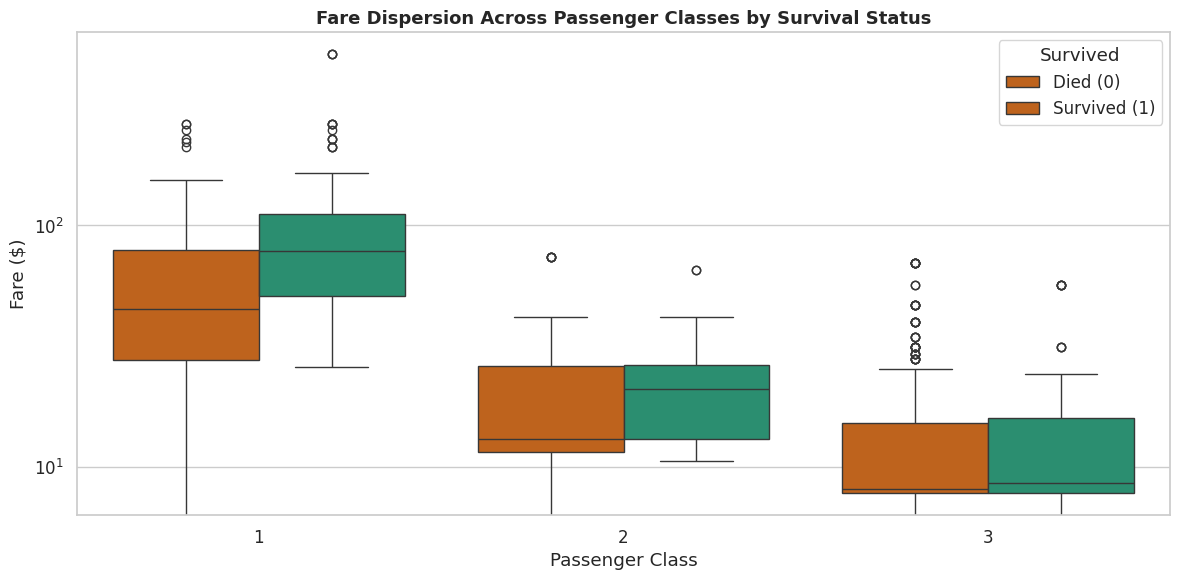

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='pclass', y='fare', hue='survived', data=df, palette={0: '#d95f02', 1: '#1b9e77'})
plt.title('Fare Dispersion Across Passenger Classes by Survival Status', fontsize=13, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.yscale('log')  # Log scale for handling extreme fare variance
plt.legend(title='Survived', labels=['Died (0)', 'Survived (1)'])

plt.tight_layout()
plt.savefig('../images/03_fare_outliers_boxplots.png', dpi=300)
plt.show()

---

## 6. Multivariate Correlation Matrix
Computing Pearson correlation coefficients across numerical attributes.

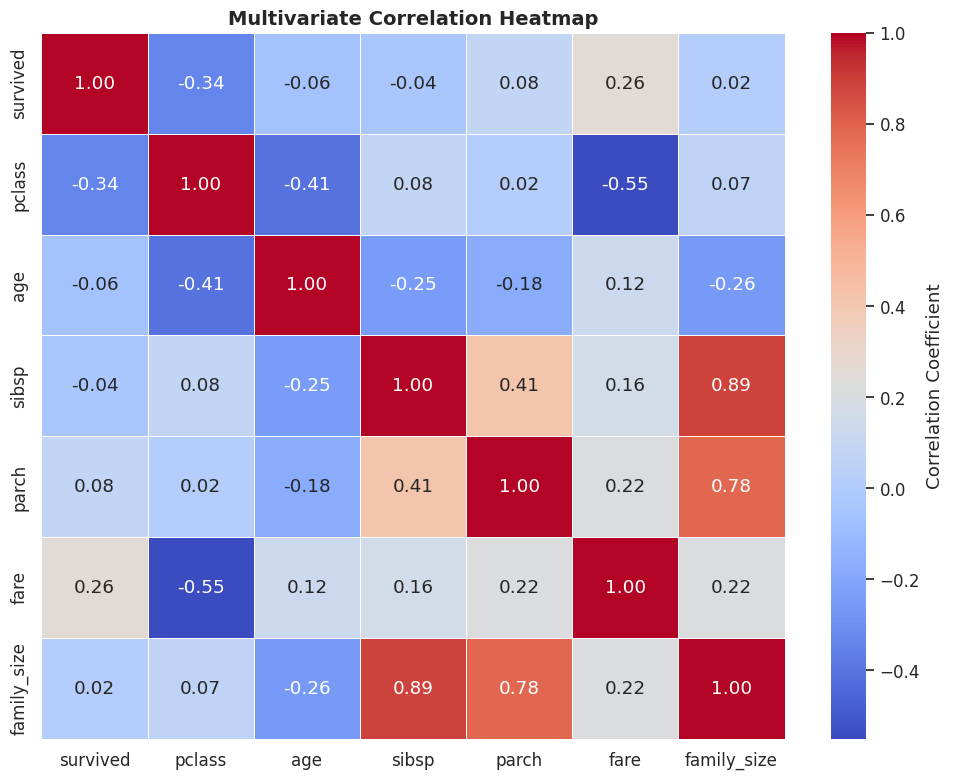

In [9]:
plt.figure(figsize=(10, 8))
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Multivariate Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/04_multivariate_correlation.png', dpi=300)
plt.show()

---

## 7. Summary & Artifact Verification

In [11]:
saved_images = [f for f in os.listdir('../images') if f.endswith('.png')]
print("Visual artifacts generated and saved for formal report embedding:")
for img in sorted(saved_images):
    print(f" - images/{img}")

Visual artifacts generated and saved for formal report embedding:
 - images/01_univariate_distributions.png
 - images/02_bivariate_survival_factors.png
 - images/03_fare_outliers_boxplots.png
 - images/04_multivariate_correlation.png
